# Task-2:Model Training and Evaluation

This notebook contains model training, Compare classificaion models for Fraud detection.


#### 1. Importing Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold

from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import confusion_matrix

from sklearn.metrics import classification_report

from sklearn.metrics import f1_score

from sklearn.metrics import precision_recall_curve

from sklearn.metrics import auc

from sklearn.metrics import roc_auc_score

from sklearn.metrics import average_precision_score

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

import os

print("All libraries imported successfully")

All libraries imported successfully


#### Loading Prepared Data from Task 1

In [2]:
fraud_df = pd.read_csv('../data/processed/fraud_data_processed.csv')

credit_df = pd.read_csv('../data/processed/creditcard_processed.csv')

fraud_df['signup_time'] = pd.to_datetime(fraud_df['signup_time'])
fraud_df['purchase_time'] = pd.to_datetime(fraud_df['purchase_time'])

print("Datasets loaded successfully")
print(f"\nFraud Data {fraud_df.shape[0]:,} rows, {fraud_df.shape[1]} columns")
print(f"Credit Card  {credit_df.shape[0]:,} rows, {credit_df.shape[1]} columns")
print(f"\nFraud Data columns:")
print(list(fraud_df.columns))

Datasets loaded successfully

Fraud Data 129,146 rows, 22 columns
Credit Card  283,726 rows, 31 columns

Fraud Data columns:
['user_id', 'signup_time', 'purchase_time', 'purchase_value', 'device_id', 'source', 'browser', 'sex', 'age', 'ip_address', 'class', 'ip_address_int', 'lower_bound_ip_address', 'upper_bound_ip_address', 'country', 'time_since_signup', 'hour_of_day', 'day_of_week', 'day_of_month', 'transaction_count', 'transaction_velocity', 'is_new_account']


### Data Preparation

In [3]:
cols_to_drop = [
    'user_id',         
    'signup_time',      
    'purchase_time',    
    'ip_address',       
    'device_id',        
]

cols_to_drop = [c for c in cols_to_drop if c in fraud_df.columns]
fraud_model_df = fraud_df.drop(columns=cols_to_drop)

cat_cols = ['source', 'browser', 'sex', 'country']
cat_cols = [c for c in cat_cols if c in fraud_model_df.columns]

fraud_model_df = pd.get_dummies(
    fraud_model_df,
    columns=cat_cols,
    drop_first=True,
    dtype=int
)

X_fraud = fraud_model_df.drop(columns=['class'])
y_fraud = fraud_model_df['class']

print("Fraud data prepared")
print(f"\nFeatures (X) shape : {X_fraud.shape}")
print(f"Target   (y) shape : {y_fraud.shape}")
print(f"\nFraud rate: {y_fraud.mean()*100:.2f}%")
print(f"Legitimate: {(y_fraud==0).sum():,}")
print(f"Fraud     : {(y_fraud==1).sum():,}")

Fraud data prepared

Features (X) shape : (129146, 199)
Target   (y) shape : (129146,)

Fraud rate: 9.50%
Legitimate: 116,878
Fraud     : 12,268


#### Preparing Credit Card Data for Modeling

In [4]:
X_credit = credit_df.drop(columns=['Class'])
y_credit = credit_df['Class']

print("Credit card data prepared")
print(f"\nFeatures (X) shape : {X_credit.shape}")
print(f"Target   (y) shape : {y_credit.shape}")
print(f"\nFraud rate: {y_credit.mean()*100:.4f}%")
print(f"Legitimate: {(y_credit==0).sum():,}")
print(f"Fraud     : {(y_credit==1).sum():,}")

Credit card data prepared

Features (X) shape : (283726, 30)
Target   (y) shape : (283726,)

Fraud rate: 0.1667%
Legitimate: 283,253
Fraud     : 473


#### Train Test Split

In [5]:
X_fraud_train, X_fraud_test, y_fraud_train, y_fraud_test = train_test_split(
    X_fraud, y_fraud,
    test_size=0.2,
    random_state=42,
    stratify=y_fraud
)

# --- Credit Card Split ---
X_credit_train, X_credit_test, y_credit_train, y_credit_test = train_test_split(
    X_credit, y_credit,
    test_size=0.2,
    random_state=42,
    stratify=y_credit
)

print("Data split complete")
print(f"\nFraud Data:")
print(f"  Training set : {X_fraud_train.shape[0]:,} rows")
print(f"  Testing set  : {X_fraud_test.shape[0]:,} rows")
print(f"  Train fraud rate : {y_fraud_train.mean()*100:.2f}%")
print(f"  Test  fraud rate : {y_fraud_test.mean()*100:.2f}%")
print(f"\nCredit Card:")
print(f"  Training set : {X_credit_train.shape[0]:,} rows")
print(f"  Testing set  : {X_credit_test.shape[0]:,} rows")
print(f"  Train fraud rate : {y_credit_train.mean()*100:.4f}%")
print(f"  Test  fraud rate : {y_credit_test.mean()*100:.4f}%")

Data split complete

Fraud Data:
  Training set : 103,316 rows
  Testing set  : 25,830 rows
  Train fraud rate : 9.50%
  Test  fraud rate : 9.50%

Credit Card:
  Training set : 226,980 rows
  Testing set  : 56,746 rows
  Train fraud rate : 0.1665%
  Test  fraud rate : 0.1674%


#### Applying SMOTE to Balance Training Data

In [6]:
smote = SMOTE(random_state=42)

# --- Apply SMOTE on Fraud Data training set ---
print("Applying SMOTE on Fraud Data...")
print(f"  Before: {(y_fraud_train==0).sum():,} legit | {(y_fraud_train==1).sum():,} fraud")

X_fraud_train_sm, y_fraud_train_sm = smote.fit_resample(
    X_fraud_train, y_fraud_train
)

print(f"  After : {(y_fraud_train_sm==0).sum():,} legit | {(y_fraud_train_sm==1).sum():,} fraud")

# --- Apply SMOTE on Credit Card training set ---
print("\nApplying SMOTE on Credit Card Data...")
print(f"  Before: {(y_credit_train==0).sum():,} legit | {(y_credit_train==1).sum():,} fraud")

X_credit_train_sm, y_credit_train_sm = smote.fit_resample(
    X_credit_train, y_credit_train
)

print(f"  After : {(y_credit_train_sm==0).sum():,} legit | {(y_credit_train_sm==1).sum():,} fraud")

print("\nSMOTE applied successfully on both datasets")
print("Test sets remain untouched")

Applying SMOTE on Fraud Data...
  Before: 93,502 legit | 9,814 fraud
  After : 93,502 legit | 93,502 fraud

Applying SMOTE on Credit Card Data...
  Before: 226,602 legit | 378 fraud
  After : 226,602 legit | 226,602 fraud

SMOTE applied successfully on both datasets
Test sets remain untouched


### Scale the Data

In [7]:
scaler_fraud = StandardScaler()
scaler_credit = StandardScaler()

# --- Scale Fraud Data ---
X_fraud_train_scaled = scaler_fraud.fit_transform(X_fraud_train_sm)

# NEVER fit on test data
X_fraud_test_scaled = scaler_fraud.transform(X_fraud_test)

# --- Scale Credit Card Data ---
X_credit_train_scaled = scaler_credit.fit_transform(X_credit_train_sm)
X_credit_test_scaled = scaler_credit.transform(X_credit_test)

print("Scaling complete")
print(f"\nFraud training set shape  : {X_fraud_train_scaled.shape}")
print(f"Fraud testing set shape   : {X_fraud_test_scaled.shape}")
print(f"\nCredit training set shape : {X_credit_train_scaled.shape}")
print(f"Credit testing set shape  : {X_credit_test_scaled.shape}")

Scaling complete

Fraud training set shape  : (187004, 199)
Fraud testing set shape   : (25830, 199)

Credit training set shape : (453204, 30)
Credit testing set shape  : (56746, 30)


### Training Models

#### Helper Function to evaluate ANY Model

In [8]:
def evaluate_model(model, X_test, y_test, model_name, dataset_name):
 
     # Get predictions
    y_pred = model.predict(X_test)

    # predict_proba() 
    y_prob = model.predict_proba(X_test)[:, 1]

    f1 = f1_score(y_test, y_pred)
    auc_pr = average_precision_score(y_test, y_prob)

    # Confusion Matrix → shows all 4 outcomes
    cm = confusion_matrix(y_test, y_pred)

    # --- Print Results ---
    print(f"  {model_name} — {dataset_name}")
    print(f"  F1 Score : {f1:.4f}")
    print(f"  AUC-PR   : {auc_pr:.4f}")
    print(f"\n  Classification Report:")
    print(classification_report(y_test, y_pred,
          target_names=['Legitimate', 'Fraud']))

    # --- Plot Confusion Matrix ---
    plt.figure(figsize=(6, 4))
    sns.heatmap(
        cm,
        annot=True,          
        fmt='d',              
        cmap='Blues',         
        xticklabels=['Legitimate', 'Fraud'],
        yticklabels=['Legitimate', 'Fraud']
    )
    plt.title(f'Confusion Matrix\n{model_name} — {dataset_name}')
    plt.ylabel('Actual')      
    plt.xlabel('Predicted')   
    plt.tight_layout()

    # Save the chart
    os.makedirs('../data/processed', exist_ok=True)
    filename = f"../data/processed/cm_{model_name.replace(' ','_')}_{dataset_name.replace(' ','_')}.png"
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()

    # Return metrics
    return {'model': model_name, 'dataset': dataset_name,
            'f1': round(f1, 4), 'auc_pr': round(auc_pr, 4)}

print("Evaluation function ready")

Evaluation function ready


### Baseline Model - Logistic Regression

Training Logistic Regression...
Logistic Regression trained on Fraud Data
  Logistic Regression — Fraud Data
  F1 Score : 0.5773
  AUC-PR   : 0.6368

  Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.95      0.96      0.96     23376
       Fraud       0.59      0.56      0.58      2454

    accuracy                           0.92     25830
   macro avg       0.77      0.76      0.77     25830
weighted avg       0.92      0.92      0.92     25830



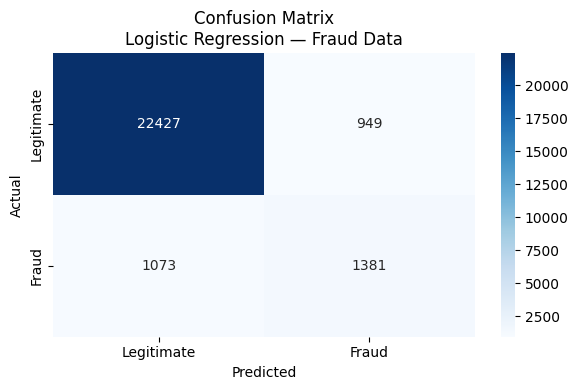

In [9]:
print("Training Logistic Regression...")

lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced', 
    random_state=42
)

# --- Train on Fraud Data ---
lr_model.fit(X_fraud_train_scaled, y_fraud_train_sm)
print("Logistic Regression trained on Fraud Data")

# --- Evaluate on Fraud Data test set ---
lr_fraud_results = evaluate_model(
    lr_model,
    X_fraud_test_scaled,
    y_fraud_test,
    "Logistic Regression",
    "Fraud Data"
)

### Logistic Regression on Credit Card

Training Logistic Regression on Credit Card Data...
Logistic Regression trained on Credit Card Data
  Logistic Regression — Credit Card
  F1 Score : 0.2440
  AUC-PR   : 0.7027

  Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      0.99      1.00     56651
       Fraud       0.14      0.85      0.24        95

    accuracy                           0.99     56746
   macro avg       0.57      0.92      0.62     56746
weighted avg       1.00      0.99      0.99     56746



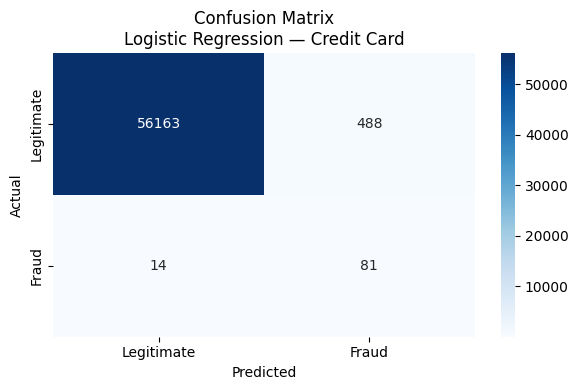

In [10]:
print("Training Logistic Regression on Credit Card Data...")

# Create fresh model for credit card data
lr_credit_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

# Train on credit card training data
lr_credit_model.fit(X_credit_train_scaled, y_credit_train_sm)
print("Logistic Regression trained on Credit Card Data")

# Evaluate on credit card test set
lr_credit_results = evaluate_model(
    lr_credit_model,
    X_credit_test_scaled,
    y_credit_test,
    "Logistic Regression",
    "Credit Card"
)

### Random Forest

#### Train Random Forest with Hyperparameter Tuning - Fraud Data

Training Random Forest on Fraud Data...
Using 93,502 rows instead of 187,004
Random Forest trained on Fraud Data
  Random Forest — Fraud Data
  F1 Score : 0.6948
  AUC-PR   : 0.6357

  Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.95      1.00      0.98     23376
       Fraud       0.95      0.55      0.69      2454

    accuracy                           0.95     25830
   macro avg       0.95      0.77      0.84     25830
weighted avg       0.95      0.95      0.95     25830



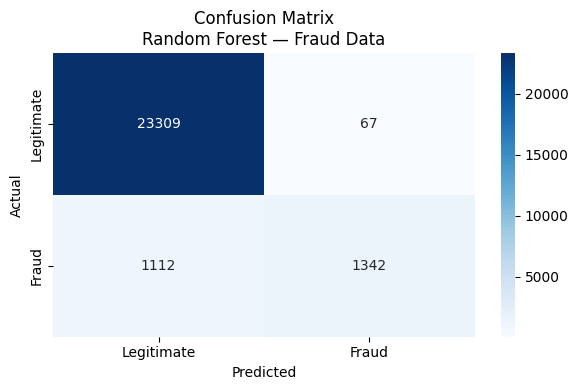

In [11]:
print("Training Random Forest on Fraud Data...")

from sklearn.utils import resample

X_sample_fraud, y_sample_fraud = resample(
    X_fraud_train_scaled,
    y_fraud_train_sm,
    n_samples=int(len(X_fraud_train_scaled) * 0.5),
    random_state=42
)

print(f"Using {len(X_sample_fraud):,} rows instead of {len(X_fraud_train_scaled):,}")


rf_fraud_model = RandomForestClassifier(
    n_estimators=100,        
    max_depth=10,             
    class_weight='balanced',  
    random_state=42,
    n_jobs=-1                 
)


rf_fraud_model.fit(X_sample_fraud, y_sample_fraud)
print("Random Forest trained on Fraud Data")


rf_fraud_results = evaluate_model(
    rf_fraud_model,
    X_fraud_test_scaled,
    y_fraud_test,
    "Random Forest",
    "Fraud Data"
)

###  Random Forest on Credit Card WITH Tuning

Training Random Forest on Credit Card Data...
Using 226,602 rows instead of 453,204
Random Forest trained on Credit Card Data
  Random Forest — Credit Card
  F1 Score : 0.6695
  AUC-PR   : 0.7924

  Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56651
       Fraud       0.56      0.83      0.67        95

    accuracy                           1.00     56746
   macro avg       0.78      0.92      0.83     56746
weighted avg       1.00      1.00      1.00     56746



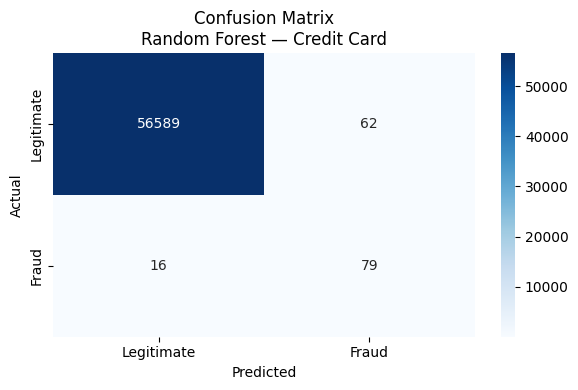

In [12]:
print("Training Random Forest on Credit Card Data...")


from sklearn.utils import resample
X_sample, y_sample = resample(
    X_credit_train_scaled,
    y_credit_train_sm,
    n_samples=int(len(X_credit_train_scaled) * 0.5),
    random_state=42
)

print(f"Using {len(X_sample):,} rows instead of {len(X_credit_train_scaled):,}")

rf_credit_model = RandomForestClassifier(
    n_estimators=100,       
    max_depth=10,            
    class_weight='balanced', 
    random_state=42,
    n_jobs=-1                
)

rf_credit_model.fit(X_sample, y_sample)
print("Random Forest trained on Credit Card Data")

rf_credit_results = evaluate_model(
    rf_credit_model,
    X_credit_test_scaled,
    y_credit_test,
    "Random Forest",
    "Credit Card"
)

### Cross Validation

In [14]:
print("Running Cross Validation...")

from sklearn.utils import resample

skf = StratifiedKFold(
    n_splits=3,        
    shuffle=True,
    random_state=42
)


X_fraud_cv, y_fraud_cv = resample(
    X_fraud_train_scaled,
    y_fraud_train_sm,
    n_samples=int(len(X_fraud_train_scaled) * 0.3),
    random_state=42
)

X_credit_cv, y_credit_cv = resample(
    X_credit_train_scaled,
    y_credit_train_sm,
    n_samples=int(len(X_credit_train_scaled) * 0.3),
    random_state=42
)

print(f"Fraud CV sample   : {len(X_fraud_cv):,} rows")
print(f"Credit CV sample  : {len(X_credit_cv):,} rows")


print("\nRunning Fraud Data CV...")
cv_fraud_scores = cross_val_score(
    rf_fraud_model,
    X_fraud_cv,
    y_fraud_cv,
    cv=skf,
    scoring='f1',
    n_jobs=-1
)

print("\n--- Fraud Data Cross Validation Results ---")
print(f"  Scores per fold : {[round(s,4) for s in cv_fraud_scores]}")
print(f"  Mean F1 Score   : {cv_fraud_scores.mean():.4f}")
print(f"  Std Deviation   : {cv_fraud_scores.std():.4f}")


print("\nRunning Credit Card CV...")
cv_credit_scores = cross_val_score(
    rf_credit_model,
    X_credit_cv,
    y_credit_cv,
    cv=skf,
    scoring='f1',
    n_jobs=-1
)

print("\n--- Credit Card Cross Validation Results ---")
print(f"  Scores per fold : {[round(s,4) for s in cv_credit_scores]}")
print(f"  Mean F1 Score   : {cv_credit_scores.mean():.4f}")
print(f"  Std Deviation   : {cv_credit_scores.std():.4f}")

print("\n Cross validation complete")

Running Cross Validation...
Fraud CV sample   : 56,101 rows
Credit CV sample  : 135,961 rows

Running Fraud Data CV...

--- Fraud Data Cross Validation Results ---
  Scores per fold : [np.float64(0.8016), np.float64(0.8075), np.float64(0.8285)]
  Mean F1 Score   : 0.8125
  Std Deviation   : 0.0115

Running Credit Card CV...

--- Credit Card Cross Validation Results ---
  Scores per fold : [np.float64(0.9917), np.float64(0.9927), np.float64(0.9931)]
  Mean F1 Score   : 0.9925
  Std Deviation   : 0.0006

 Cross validation complete


### Model Comparison and Selection

In [15]:
all_results = [
    lr_fraud_results,
    rf_fraud_results,
    lr_credit_results,
    rf_credit_results,
]

results_df = pd.DataFrame(all_results)
results_df.columns = ['Model', 'Dataset', 'F1 Score', 'AUC-PR']

results_df['CV Mean F1'] = [
    None,                          
    cv_fraud_scores.mean().round(4),  
    None,                          
    cv_credit_scores.mean().round(4), 
]

results_df['CV Std'] = [
    None,
    cv_fraud_scores.std().round(4),
    None,
    cv_credit_scores.std().round(4),
]

print("FINAL MODEL COMPARISON TABLE")
display(results_df)

FINAL MODEL COMPARISON TABLE


,Model,Dataset,F1 Score,AUC-PR,CV Mean F1,CV Std
0,Logistic Regression,Fraud Data,0.5773,0.6368,NaN,NaN
1,Random Forest,Fraud Data,0.6948,0.6357,0.8125,0.0115
2,Logistic Regression,Credit Card,0.2440,0.7027,NaN,NaN
3,Random Forest,Credit Card,0.6695,0.7924,0.9925,0.0006


### Comparison Bar Chart

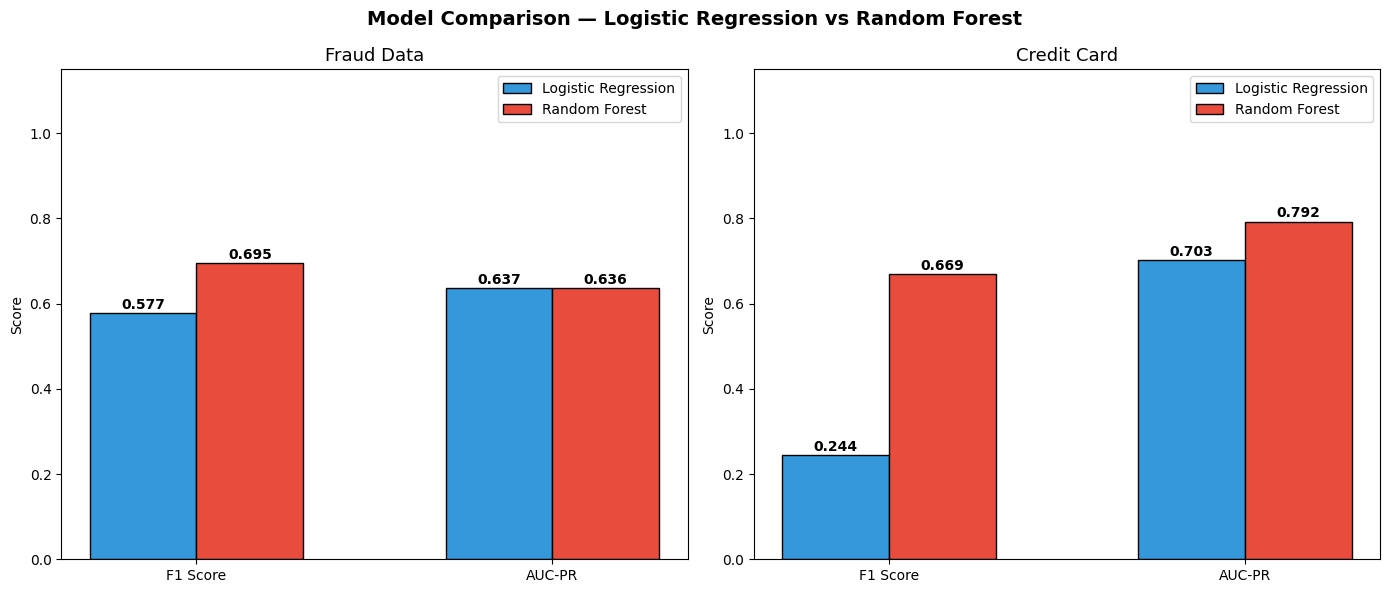

Comparison chart saved


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    'Model Comparison — Logistic Regression vs Random Forest',
    fontsize=14, fontweight='bold'
)

colors = ['#3498db', '#e74c3c']
datasets = ['Fraud Data', 'Credit Card']
metrics = ['F1 Score', 'AUC-PR']

for idx, dataset in enumerate(datasets):

    subset = results_df[results_df['Dataset'] == dataset]

    x = np.arange(len(metrics))
    width = 0.3

    # Get values for each model
    lr_vals = subset[subset['Model'] == 'Logistic Regression'][
        ['F1 Score', 'AUC-PR']
    ].values[0]

    rf_vals = subset[subset['Model'] == 'Random Forest'][
        ['F1 Score', 'AUC-PR']
    ].values[0]

    # Plot bars side by side
    bars1 = axes[idx].bar(
        x - width/2, lr_vals, width,
        label='Logistic Regression',
        color='#3498db', edgecolor='black'
    )
    bars2 = axes[idx].bar(
        x + width/2, rf_vals, width,
        label='Random Forest',
        color='#e74c3c', edgecolor='black'
    )

    # Add value labels on each bar
    for bar in bars1:
        axes[idx].text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{bar.get_height():.3f}',
            ha='center', fontsize=10, fontweight='bold'
        )
    for bar in bars2:
        axes[idx].text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{bar.get_height():.3f}',
            ha='center', fontsize=10, fontweight='bold'
        )

    axes[idx].set_title(f'{dataset}', fontsize=13)
    axes[idx].set_ylabel('Score')
    axes[idx].set_ylim(0, 1.15)
    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels(metrics)
    axes[idx].legend()

plt.tight_layout()
plt.savefig('../data/processed/model_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Comparison chart saved")

### Saving the Model

In [17]:
import joblib
import os

# Create models folder
os.makedirs('../models', exist_ok=True)

# Save all 4 trained models
joblib.dump(lr_model,        '../models/lr_fraud_model.pkl')
joblib.dump(lr_credit_model, '../models/lr_credit_model.pkl')
joblib.dump(rf_fraud_model,  '../models/rf_fraud_model.pkl')
joblib.dump(rf_credit_model, '../models/rf_credit_model.pkl')

print("All models saved successfully")
print("\nSaved files:")
print("models/lr_fraud_model.pkl")
print("models/lr_credit_model.pkl")
print("models/rf_fraud_model.pkl")
print("models/rf_credit_model.pkl")

All models saved successfully

Saved files:
models/lr_fraud_model.pkl
models/lr_credit_model.pkl
models/rf_fraud_model.pkl
models/rf_credit_model.pkl


### Model Selection Justification

---
## Model Selection — Final Decision

### Comparison Summary

| Model | Dataset | F1 Score | AUC-PR | CV Mean F1 | CV Std |
|---|---|---|---|---|---|
| Logistic Regression | Fraud Data | 0.5773 | 0.6368 | — | — |
| Random Forest | Fraud Data | 0.6948 | 0.6357 | 0.8125 | 0.0115 |
| Logistic Regression | Credit Card | 0.2440 | 0.7027 | — | — |
| Random Forest | Credit Card | 0.6695 | 0.7924 | 0.9925 | 0.0006 |

---

### Selected Model — Random Forest

**Reason 1 — Better F1 Score on Both Datasets**
Random Forest scored 0.6948 vs 0.5773 on Fraud Data
and 0.6695 vs 0.2440 on Credit Card Data.
F1 Score directly measures how well the model catches
fraud without blocking too many good customers.
Random Forest wins clearly on both datasets.

**Reason 2 — Better AUC-PR on Credit Card**
AUC-PR measures overall fraud detection ability
across all decision thresholds.
Random Forest scored 0.7924 vs 0.7027 on Credit Card.
This means Random Forest is better at ranking
fraud transactions above legitimate ones.

**Reason 3 — Consistent Cross Validation**
- Fraud Data CV   → 0.8125 ± 0.0115 (very consistent)
- Credit Card CV  → 0.9925 ± 0.0006 (near perfect)

Low standard deviation means the model performs
reliably on unseen data — not just memorizing training data.

**Reason 4 — Handles Severe Imbalance Better**
Credit Card data has only 0.17% fraud.
Random Forest with class_weight=balanced
handles this extreme imbalance much better than
Logistic Regression — F1 jumped from 0.244 to 0.669.

**Reason 5 — Explainable for Business Use**
Random Forest provides feature importance scores.
This tells us WHICH features matter most for fraud detection.
In financial services, being able to explain WHY
a transaction was blocked is essential for
customer trust and regulatory compliance.

---

### Why Not Logistic Regression?

Logistic Regression is a straight line separator.
It cannot learn complex non-linear fraud patterns.
Its F1 Score of 0.244 on Credit Card data means
it misses the majority of fraud cases which is
unacceptable for a real fraud detection system.
It is useful only as a baseline comparison point.